# Board Game Recommender — Exploratory Data Analysis

**Dataset**: BoardGameGeek Reviews (Kaggle) — `jvanelteren/boardgamegeek-reviews`

This notebook profiles the BGG dataset that feeds the Phase 1 modeling pipeline.
Each section produces report-ready numbers and plots. We describe the data twice:

1. **Raw** — every valid review row.
2. **Filtered** — after applying the modeling filter (users ≥ 5 ratings, games ≥ 20 ratings),
   which is the set our models actually train on.

The split between the two is the most important framing for the report: it shows what
got thrown away and why the models see a denser, less skewed slice of reality than the
raw download suggests.

Run cells top-to-bottom. Most plots are saved to `./eda_figures/` as PNGs so they can be
dropped straight into a report.

## 1. Setup

In [1]:
# Colab: optional drive mount for caching the dataset zip
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount('/content/drive')
    except Exception as e:
        print(f"Drive mount skipped: {e}")

!pip install -q kaggle pandas numpy matplotlib seaborn

Drive mount skipped: mount failed


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent figure styling
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = './eda_figures'
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

def savefig(name):
    path = f"{FIG_DIR}/{name}.png"
    plt.savefig(path)
    print(f"  saved -> {path}")

## 2. Load Dataset

Same Kaggle download path as the Phase 1 notebook. Upload `kaggle.json` to Colab once
(Account → Create New API Token) and this cell will fetch + unzip on the first run.

In [3]:
if IN_COLAB and not os.path.exists('/root/.kaggle/kaggle.json'):
    from google.colab import files
    print("Upload your kaggle.json:")
    files.upload()
    !mkdir -p /root/.kaggle
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

if not os.path.exists('boardgamegeek-reviews.zip'):
    !kaggle datasets download -d jvanelteren/boardgamegeek-reviews

if not os.path.exists('bgg_data'):
    !unzip -q boardgamegeek-reviews.zip -d bgg_data

!ls -lh bgg_data

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jvanelteren/boardgamegeek-reviews
License(s): other
100% 1.61G/1.61G [00:23<00:00, 73.3MB/s]

total 5.1G
-rw-r--r-- 1 root root 3.6M Feb  1  2025 2020-08-19.csv
-rw-r--r-- 1 root root 4.9M Feb  1  2025 2022-01-08.csv
-rw-r--r-- 1 root root 1.3G Feb  1  2025 bgg-15m-reviews.csv
-rw-r--r-- 1 root root 1.6G Feb  1  2025 bgg-19m-reviews.csv
-rw-r--r-- 1 root root 2.1G Feb  1  2025 bgg-26m-reviews.csv
-rw-r--r-- 1 root root 105M Feb  1  2025 games_detailed_info2025.csv
-rw-r--r-- 1 root root  95M Feb  1  2025 games_detailed_info.csv


In [4]:
DATA_DIR = 'bgg_data'

# Reviews: pull a slightly wider column set than Phase 1 — we want `comment` for
# text-length analysis. Same dropna/range filter as Phase 1 so the row counts
# match exactly.
reviews_raw = pd.read_csv(
    f'{DATA_DIR}/bgg-19m-reviews.csv',
    usecols=['user', 'rating', 'comment', 'ID', 'name'],
)
reviews_raw = reviews_raw.rename(columns={'ID': 'game_id'})
reviews_raw = reviews_raw.dropna(subset=['user', 'rating', 'game_id'])
reviews_raw['rating'] = reviews_raw['rating'].astype(float)
reviews_raw = reviews_raw[(reviews_raw['rating'] >= 1) & (reviews_raw['rating'] <= 10)]
reviews_raw = reviews_raw.reset_index(drop=True)

# Game metadata
games = pd.read_csv(f'{DATA_DIR}/games_detailed_info.csv', low_memory=False)

print(f"Raw reviews: {len(reviews_raw):,}")
print(f"Raw users:   {reviews_raw['user'].nunique():,}")
print(f"Raw games:   {reviews_raw['game_id'].nunique():,}")
print(f"Games table: {len(games):,} rows, {games['id'].nunique():,} unique ids")

Raw reviews: 18,964,728
Raw users:   412,815
Raw games:   21,839
Games table: 21,631 rows, 21,631 unique ids


## 3. Apply Modeling Filter

We keep two DataFrames around for the rest of the notebook:

- `reviews_raw` — everything that survived the validity checks above.
- `reviews_filt` — additionally requires users with ≥ 5 ratings and games with ≥ 20 ratings.
  Iterated 3× because removing low-volume games can drop a user below the threshold, and vice
  versa. This is **the same filter the Phase 1 models train on**.

In [5]:
MIN_USER_RATINGS = 5
MIN_GAME_RATINGS = 20

reviews_filt = reviews_raw.copy()
for _ in range(3):
    ucounts = reviews_filt['user'].value_counts()
    gcounts = reviews_filt['game_id'].value_counts()
    reviews_filt = reviews_filt[
        reviews_filt['user'].isin(ucounts[ucounts >= MIN_USER_RATINGS].index)
        & reviews_filt['game_id'].isin(gcounts[gcounts >= MIN_GAME_RATINGS].index)
    ]
reviews_filt = reviews_filt.reset_index(drop=True)

def shape_summary(df, label):
    return {
        'set': label,
        'reviews': len(df),
        'users': df['user'].nunique(),
        'games': df['game_id'].nunique(),
        'avg_ratings_per_user': len(df) / df['user'].nunique(),
        'avg_ratings_per_game': len(df) / df['game_id'].nunique(),
        'density_pct': 100 * len(df) / (df['user'].nunique() * df['game_id'].nunique()),
    }

shape_df = pd.DataFrame([
    shape_summary(reviews_raw, 'raw'),
    shape_summary(reviews_filt, 'filtered (≥5 user / ≥20 game)'),
])
print(shape_df.to_string(index=False))

                          set  reviews  users  games  avg_ratings_per_user  avg_ratings_per_game  density_pct
                          raw 18964728 412815  21839             45.940017            868.388113     0.210358
filtered (≥5 user / ≥20 game) 18716519 272319  21802             68.730125            858.477158     0.315247


**Read this table first.** The filter throws away roughly the long tail of
one-and-done users and obscure games. Density (the % of the user×game matrix that has a
rating) goes up by a small absolute amount but a meaningful relative one — which is what
the collaborative-filtering models care about.

## 4. Rating Distribution

BGG ratings are 1–10, often with decimals. We bin to integer for the headline histogram
and report the raw decimal-aware stats in a table.

In [6]:
def rating_stats(df):
    r = df['rating']
    return {
        'mean': r.mean(),
        'median': r.median(),
        'std': r.std(),
        'p10': r.quantile(0.10),
        'p90': r.quantile(0.90),
        'pct_integer': 100 * (r == r.round()).mean(),
    }

stats = pd.DataFrame({
    'raw': rating_stats(reviews_raw),
    'filtered': rating_stats(reviews_filt),
}).T
print(stats.round(3).to_string())

           mean  median    std  p10  p90  pct_integer
raw       7.082     7.0  1.596  5.0  9.0       82.964
filtered  7.063     7.0  1.586  5.0  9.0       82.808


  saved -> ./eda_figures/01_rating_distribution.png


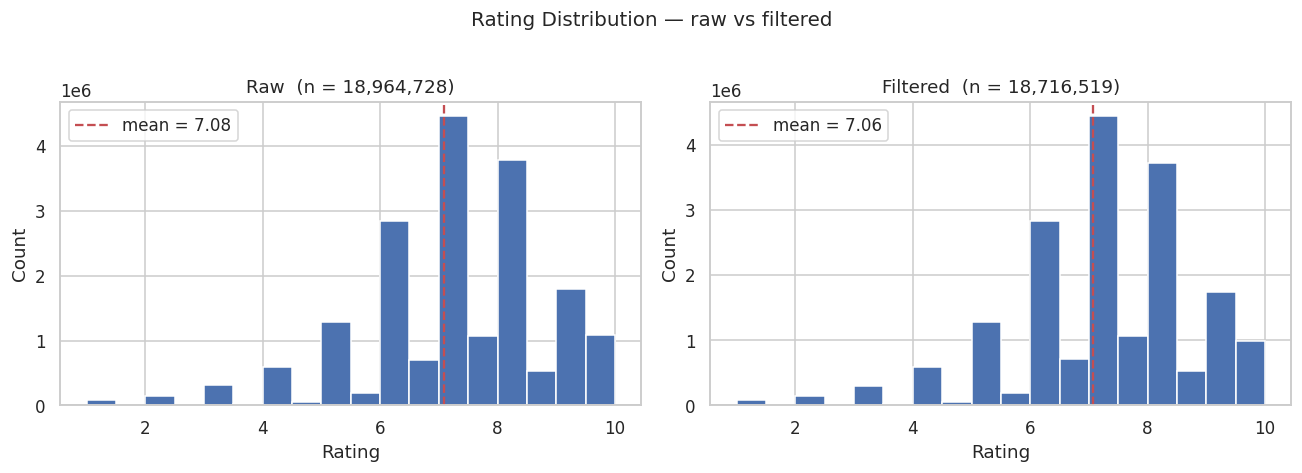

In [7]:
# Plot 1: rating histogram (raw vs filtered, overlaid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)

for ax, df, label in [(axes[0], reviews_raw, 'Raw'),
                      (axes[1], reviews_filt, 'Filtered')]:
    # Bin to half-integer for a cleaner view; ratings can be like 7.5
    bins = np.arange(1.0, 10.5, 0.5)
    ax.hist(df['rating'], bins=bins, color='#4C72B0', edgecolor='white')
    ax.set_title(f"{label}  (n = {len(df):,})")
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.axvline(df['rating'].mean(), color='#C44E52', linestyle='--',
               label=f"mean = {df['rating'].mean():.2f}")
    ax.legend()

plt.suptitle('Rating Distribution — raw vs filtered', y=1.02, fontsize=13)
plt.tight_layout()
savefig('01_rating_distribution')
plt.show()

**What to note in the report.** Ratings are heavily left-skewed: users on BGG mostly
log games they liked, so the mass sits between 6 and 8. The filter barely shifts the mean
(by design — it removes low-volume users/games, not low/high ratings). For RMSE-style
metrics this matters: a "predict the global mean" baseline is already close to 1.4 RMSE
and beating it requires *real* personalization.

## 5. Activity Distributions

The defining feature of this dataset is its long tail. Most users rate a handful of games;
most games receive few ratings. We plot on a log-log axis because that's the only way the
shape is legible.

  saved -> ./eda_figures/02_activity_loglog.png


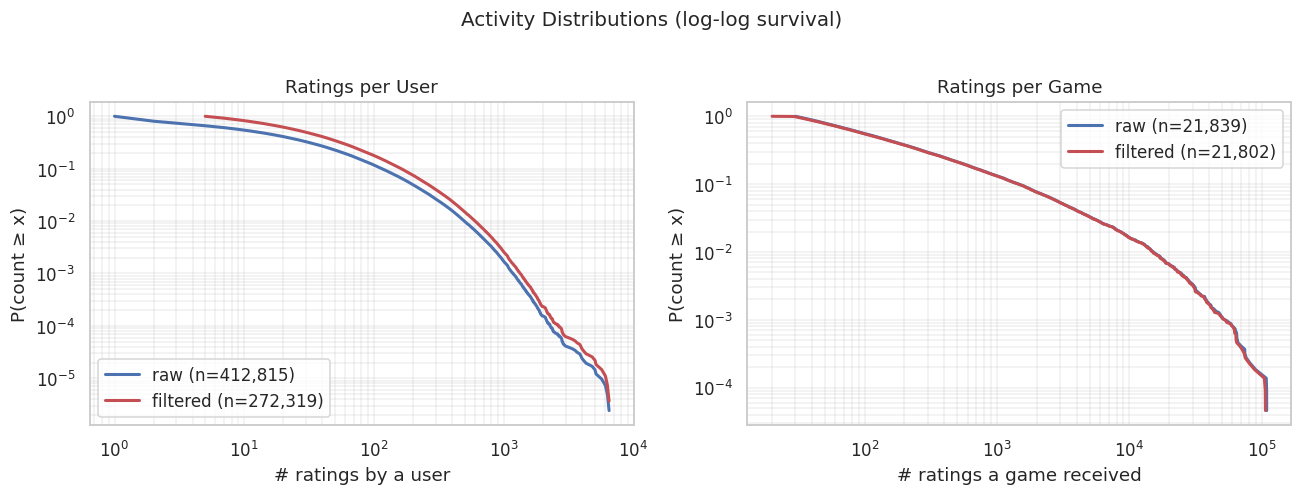

In [8]:
def activity_counts(df):
    return (df['user'].value_counts().values,
            df['game_id'].value_counts().values)

u_raw, g_raw = activity_counts(reviews_raw)
u_filt, g_filt = activity_counts(reviews_filt)

# Plot 2: ratings-per-user and ratings-per-game, log-log, raw vs filtered overlaid
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

def plot_loglog(ax, raw_arr, filt_arr, title, xlabel):
    # Survival function: P(count >= x). Reads as "fraction of users/games with >= x ratings".
    for arr, label, color in [(raw_arr, 'raw', '#4C72B0'),
                              (filt_arr, 'filtered', '#C44E52')]:
        sorted_arr = np.sort(arr)
        # x = unique counts, y = survival probability
        x = np.unique(sorted_arr)
        # Fraction of entities with count >= x
        y = 1.0 - np.searchsorted(sorted_arr, x, side='left') / len(sorted_arr)
        ax.loglog(x, y, label=f"{label} (n={len(arr):,})", color=color, linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('P(count ≥ x)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plot_loglog(axes[0], u_raw, u_filt, 'Ratings per User', '# ratings by a user')
plot_loglog(axes[1], g_raw, g_filt, 'Ratings per Game', '# ratings a game received')

plt.suptitle('Activity Distributions (log-log survival)', y=1.02, fontsize=13)
plt.tight_layout()
savefig('02_activity_loglog')
plt.show()

In [9]:

# Quantile table — easier to cite than a plot
def quantile_table(arr, label):
    qs = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
    return pd.Series({f'p{int(q*1000)/10}': int(np.quantile(arr, q)) for q in qs}, name=label)

quant_df = pd.concat([
    quantile_table(u_raw, 'ratings/user (raw)'),
    quantile_table(u_filt, 'ratings/user (filtered)'),
    quantile_table(g_raw, 'ratings/game (raw)'),
    quantile_table(g_filt, 'ratings/game (filtered)'),
], axis=1).T
quant_df['max'] = [u_raw.max(), u_filt.max(), g_raw.max(), g_filt.max()]
print(quant_df.to_string())

                         p50.0  p75.0  p90.0  p95.0  p99.0  p99.9     max
ratings/user (raw)          12     44    115    197    496   1178    6471
ratings/user (filtered)     29     71    161    261    600   1334    6471
ratings/game (raw)         122    393   1460   3218  15135  50893  108971
ratings/game (filtered)    120    388   1448   3199  14949  50444  106666


**Report angle.** Half of raw users rated ≤ 2 games — that's the cohort the filter
cuts. The remaining tail is still long: a small number of power users contribute a
disproportionate share of rows. This justifies leave-one-out (every user has at least 5
ratings post-filter, so holding out 2 is safe) and motivates the Bayesian shrinkage in the
popularity baseline (a game with 3 ratings of 10 should *not* outrank a game with 5000
ratings averaging 8.5).

## 6. Sparsity & Coverage

Sparsity = `1 - n_reviews / (n_users * n_games)`. A density of even 1% would be
"dense" for a recommender; we're going to land orders of magnitude below that.

In [10]:
def sparsity(df):
    nu = df['user'].nunique()
    ng = df['game_id'].nunique()
    cells = nu * ng
    filled = len(df)
    return {
        'users': nu, 'games': ng, 'cells (users*games)': cells,
        'ratings': filled,
        'density': filled / cells,
        'sparsity_pct': 100 * (1 - filled / cells),
    }

spars = pd.DataFrame({
    'raw': sparsity(reviews_raw),
    'filtered': sparsity(reviews_filt),
}).T

# Pretty-print with thousands separators for big counts
for col in ['users', 'games', 'cells (users*games)', 'ratings']:
    spars[col] = spars[col].apply(lambda x: f"{int(x):,}")
spars['density'] = spars['density'].apply(lambda x: f"{x:.6%}")
spars['sparsity_pct'] = spars['sparsity_pct'].apply(lambda x: f"{x:.4f}%")
print(spars.to_string())

            users   games cells (users*games)     ratings    density sparsity_pct
raw       412,815  21,839       9,015,466,785  18,964,728  0.210358%     99.7896%
filtered  272,319  21,802       5,937,098,838  18,716,519  0.315247%     99.6848%


## 7. Top Games — Naive vs. Bayesian-Weighted

This previews the popularity baseline's whole reason for existing.

In [11]:
# We use the filtered set because that's what the baseline trains on.
g_stats = reviews_filt.groupby(['game_id', 'name'])['rating'].agg(['mean', 'count']).reset_index()
g_stats = g_stats.rename(columns={'mean': 'avg_rating', 'count': 'n_ratings'})

# Naive: just sort by avg_rating, no minimum
naive_top = g_stats.nlargest(15, 'avg_rating')[['name', 'avg_rating', 'n_ratings']]

# Bayesian: same formula as Phase 1 baseline
C = reviews_filt['rating'].mean()
m = float(g_stats['n_ratings'].quantile(0.75))
g_stats['bayes_score'] = (
    (g_stats['n_ratings'] / (g_stats['n_ratings'] + m)) * g_stats['avg_rating']
    + (m / (g_stats['n_ratings'] + m)) * C
)
bayes_top = g_stats.nlargest(15, 'bayes_score')[['name', 'avg_rating', 'n_ratings', 'bayes_score']]

print(f"Global mean (C) = {C:.3f}   Smoothing m (75th pct of counts) = {m:.0f}")
print()
print("=== Top 15 by NAIVE average rating ===")
print(naive_top.to_string(index=False))
print()
print("=== Top 15 by BAYESIAN-WEIGHTED score ===")
print(bayes_top.round(3).to_string(index=False))

Global mean (C) = 7.063   Smoothing m (75th pct of counts) = 388

=== Top 15 by NAIVE average rating ===
                                                                  name  avg_rating  n_ratings
                 System Gateway (fan expansion for Android: Netrunner)    9.434783         46
                                                                 Erune    9.380952         21
                                                              DEFCON 1    9.307097         31
                                               Wings of the Motherland    9.260000         75
         Primer: The Gamer's Source for Battles from the Age of Reason    9.119433         60
                                                 The Cones of Dunshire    9.093750         32
                        Panzers Last Stand: Battles for Budapest, 1945    9.054054         37
The Third Winter: The Battle for the Ukraine September 1943-April 1944    9.037037         27
                                              Mal

**Report angle.** The naive list is usually noise — niche games with a handful of
10s. The Bayesian list is the recognizable BGG canon (Gloomhaven, Brass, Spirit Island,
Twilight Struggle, etc.). This is the most concrete possible demonstration of *why*
shrinkage matters; it's worth a paragraph and the table in the report.

## 8. Metadata Coverage

The content-based model relies on category/mechanic/family/designer/description fields.
We need to know how often each is populated — and how often we'd be stuck with empty
strings.

In [12]:
# Restrict to games that appear in the filtered reviews — those are what the model scores
in_use = set(reviews_filt['game_id'].unique())
games_in_use = games[games['id'].isin(in_use)].copy()
print(f"Games appearing in filtered reviews: {games_in_use['id'].nunique():,}")
print(f"Of which present in metadata table: {len(games_in_use):,}")
print(f"Coverage: {100 * len(games_in_use) / len(in_use):.2f}%")

Games appearing in filtered reviews: 21,589
Of which present in metadata table: 21,589
Coverage: 99.02%


In [13]:
# Field-by-field non-empty coverage on the in-use games
text_fields = ['boardgamecategory', 'boardgamemechanic', 'boardgamefamily',
               'boardgamedesigner', 'description']
numeric_fields = ['yearpublished', 'minplayers', 'maxplayers', 'playingtime',
                  'average', 'usersrated']

def pct_nonempty(s):
    s = s.fillna('').astype(str).str.strip()
    return 100 * (s != '').mean()

def pct_nonnull(s):
    return 100 * s.notna().mean()

coverage = []
for f in text_fields:
    if f in games_in_use.columns:
        coverage.append({'field': f, 'type': 'text', 'pct_present': pct_nonempty(games_in_use[f])})
for f in numeric_fields:
    if f in games_in_use.columns:
        coverage.append({'field': f, 'type': 'numeric', 'pct_present': pct_nonnull(games_in_use[f])})

cov_df = pd.DataFrame(coverage).sort_values('pct_present', ascending=False)
print(cov_df.round(2).to_string(index=False))

            field    type  pct_present
      playingtime numeric       100.00
    yearpublished numeric       100.00
       minplayers numeric       100.00
          average numeric       100.00
       usersrated numeric       100.00
       maxplayers numeric       100.00
      description    text       100.00
boardgamecategory    text        98.69
boardgamedesigner    text        97.24
boardgamemechanic    text        92.65
  boardgamefamily    text        82.63


  saved -> ./eda_figures/03_metadata_coverage.png


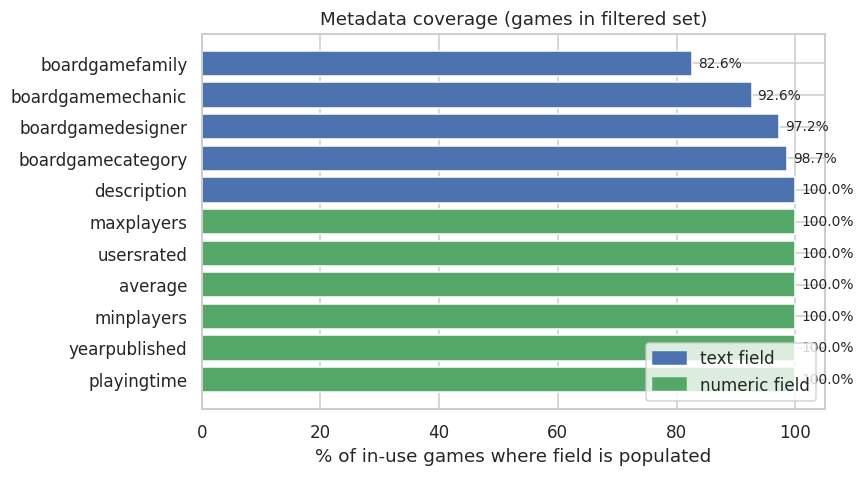

In [14]:
# Plot 3: metadata coverage as a horizontal bar
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#4C72B0' if t == 'text' else '#55A868' for t in cov_df['type']]
ax.barh(cov_df['field'], cov_df['pct_present'], color=colors, edgecolor='white')
ax.set_xlabel('% of in-use games where field is populated')
ax.set_xlim(0, 105)
ax.set_title('Metadata coverage (games in filtered set)')
for i, (f, p) in enumerate(zip(cov_df['field'], cov_df['pct_present'])):
    ax.text(p + 1, i, f"{p:.1f}%", va='center', fontsize=9)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C72B0', label='text field'),
                   Patch(color='#55A868', label='numeric field')],
          loc='lower right')
plt.tight_layout()
savefig('03_metadata_coverage')
plt.show()

## 9. Mechanics & Categories — the Content-Based Vocabulary

The TF-IDF model in Phase 1 builds tokens from these list-string columns. This section
shows the actual distribution it's working with.

In [15]:
def parse_list_string(s):
    """Convert "['Dice Rolling', 'Set Collection']" -> ['Dice Rolling', 'Set Collection'].

    Tolerant of malformed input; falls back to a stripped split. Matches the
    spirit (not exact tokenization) of the Phase 1 content_features cleaner.
    """
    if not isinstance(s, str) or s == '' or s == '[]':
        return []
    # Try literal_eval first
    try:
        import ast
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(x).strip() for x in v if str(x).strip()]
    except Exception:
        pass
    # Fallback: strip brackets/quotes and split on commas
    cleaned = s.replace('[', '').replace(']', '').replace("'", '').replace('"', '')
    return [t.strip() for t in cleaned.split(',') if t.strip()]

from collections import Counter

def field_counter(df, col):
    c = Counter()
    for s in df[col].fillna(''):
        for tok in parse_list_string(s):
            c[tok] += 1
    return c

cat_counter = field_counter(games_in_use, 'boardgamecategory')
mech_counter = field_counter(games_in_use, 'boardgamemechanic')

print(f"Unique categories: {len(cat_counter):,}   (top: {cat_counter.most_common(3)})")
print(f"Unique mechanics:  {len(mech_counter):,}   (top: {mech_counter.most_common(3)})")

Unique categories: 84   (top: [('Card Game', 6381), ('Wargame', 3819), ('Fantasy', 2673)])
Unique mechanics:  182   (top: [('Dice Rolling', 6103), ('Hand Management', 4407), ('Set Collection', 2931)])


  saved -> ./eda_figures/04_categories_mechanics.png


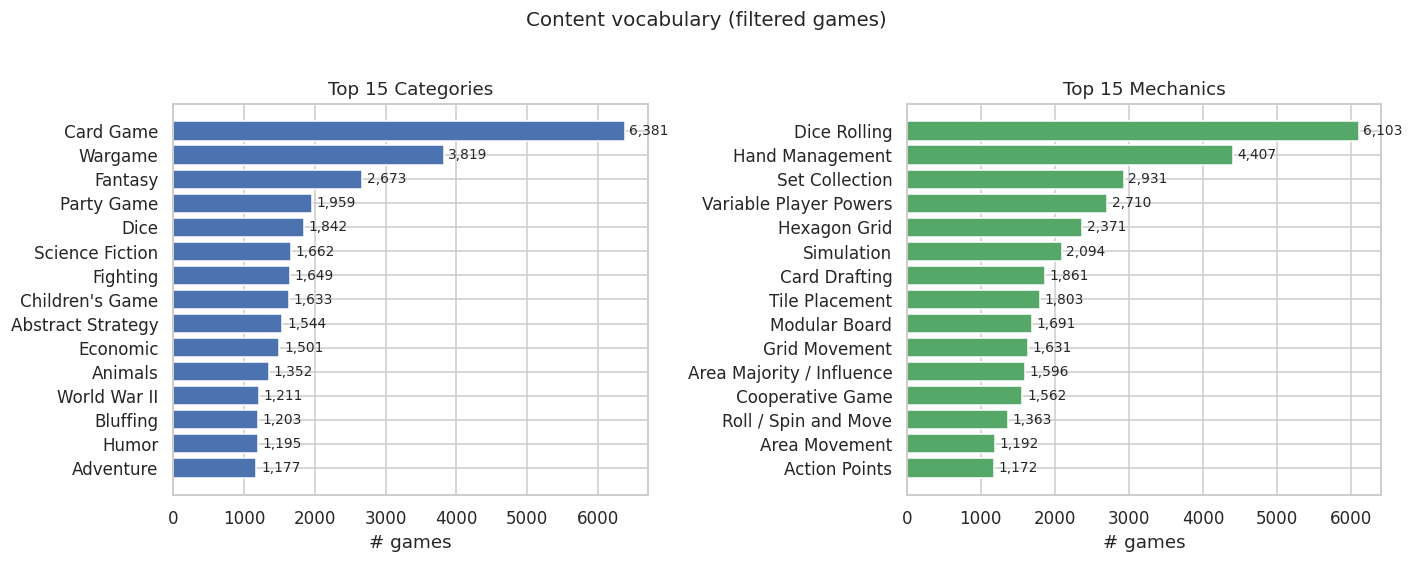

In [16]:
# Plot 4: top 15 categories and mechanics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, counter, title, color in [
    (axes[0], cat_counter, 'Top 15 Categories', '#4C72B0'),
    (axes[1], mech_counter, 'Top 15 Mechanics', '#55A868'),
]:
    top = counter.most_common(15)
    labels = [k for k, _ in top][::-1]
    counts = [v for _, v in top][::-1]
    ax.barh(labels, counts, color=color, edgecolor='white')
    ax.set_xlabel('# games')
    ax.set_title(title)
    for i, c in enumerate(counts):
        ax.text(c + max(counts) * 0.01, i, f"{c:,}", va='center', fontsize=9)

plt.suptitle('Content vocabulary (filtered games)', y=1.02, fontsize=13)
plt.tight_layout()
savefig('04_categories_mechanics')
plt.show()

**Report angle.** A few high-frequency mechanics ("Dice Rolling", "Hand Management",
"Set Collection") dominate; the tail is long. This is *exactly* the signal a TF-IDF
weighting downweights — common-everywhere tokens get less discriminative power, rare ones
get more. Worth saying explicitly in the methodology section.

## 10. Publication Year — is the dataset historically lopsided?

A recommender trained on data where 90% of games come from one decade can struggle on
older or newer titles. This is also relevant if you ever bring in a time-based split.

In [17]:
year = pd.to_numeric(games_in_use['yearpublished'], errors='coerce')
year = year[(year >= 1900) & (year <= 2025)]

print(f"Year stats (in-use games, 1900–2025 window):")
print(year.describe().round(1).to_string())

Year stats (in-use games, 1900–2025 window):
count    21292.0
mean      2007.1
std         13.7
min       1900.0
25%       2002.0
50%       2012.0
75%       2017.0
max       2023.0


  saved -> ./eda_figures/05_year_distribution.png


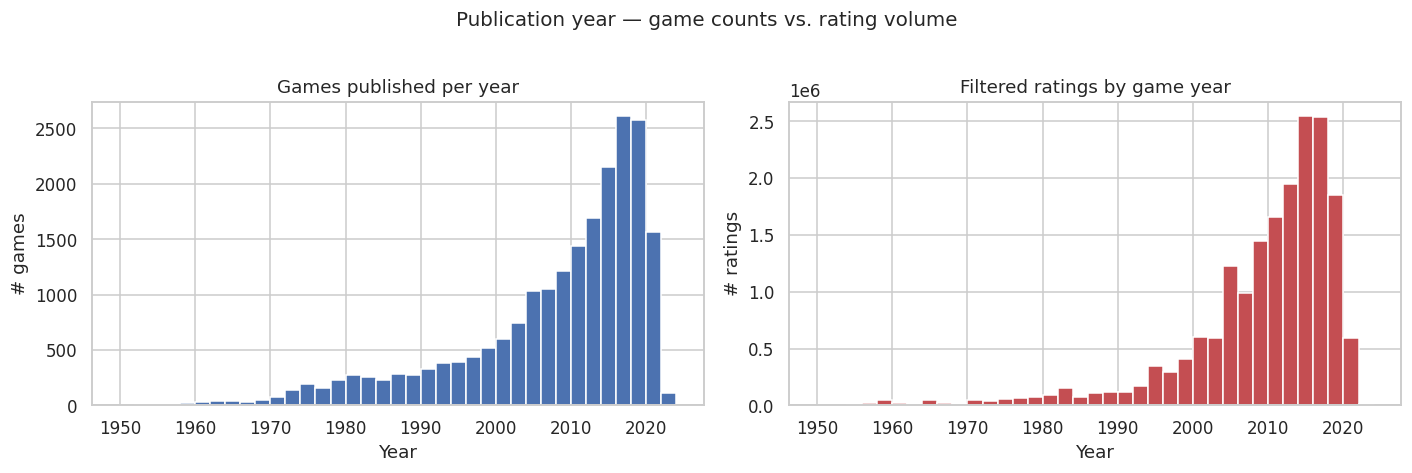

In [18]:
# Also weight by rating volume (a 1970 game with 50K ratings matters more than 50 obscure
# 1970 games combined). Compute reviews-per-year using a id->year map.
year_map = dict(zip(games_in_use['id'], pd.to_numeric(games_in_use['yearpublished'], errors='coerce')))
reviews_filt['year'] = reviews_filt['game_id'].map(year_map)
reviews_year = reviews_filt['year'].dropna()
reviews_year = reviews_year[(reviews_year >= 1900) & (reviews_year <= 2025)].astype(int)

# Plot 5: dual histogram — games per year vs ratings per year
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

bins = np.arange(1950, 2026, 2)
axes[0].hist(year.dropna(), bins=bins, color='#4C72B0', edgecolor='white')
axes[0].set_title('Games published per year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('# games')

axes[1].hist(reviews_year, bins=bins, color='#C44E52', edgecolor='white')
axes[1].set_title('Filtered ratings by game year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('# ratings')

plt.suptitle('Publication year — game counts vs. rating volume', y=1.02, fontsize=13)
plt.tight_layout()
savefig('05_year_distribution')
plt.show()

**Report angle.** Two stories on one row. *Games* trickle in from the 70s and
explode after ~2000. *Ratings* are even more concentrated post-2005 — the modern
hobby-board-game era. Anything published before ~1990 is a thin slice of the data; a
model that does well overall could still be poor on classic titles.

## 11. Player Count & Playing Time

Useful sanity-checks; also handy filtering knobs for a "good for 2 players, under an
hour" front-end query.

In [19]:
minp = pd.to_numeric(games_in_use['minplayers'], errors='coerce')
maxp = pd.to_numeric(games_in_use['maxplayers'], errors='coerce')
ptime = pd.to_numeric(games_in_use['playingtime'], errors='coerce')

print("minplayers:", minp.describe().round(2).to_dict())
print("maxplayers:", maxp.describe().round(2).to_dict())
print("playingtime (min):", ptime.describe().round(2).to_dict())

minplayers: {'count': 21589.0, 'mean': 2.01, 'std': 0.69, 'min': 0.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 10.0}
maxplayers: {'count': 21589.0, 'mean': 5.71, 'std': 15.12, 'min': 0.0, '25%': 4.0, '50%': 4.0, '75%': 6.0, 'max': 999.0}
playingtime (min): {'count': 21589.0, 'mean': 90.53, 'std': 535.33, 'min': 0.0, '25%': 25.0, '50%': 45.0, '75%': 90.0, 'max': 60000.0}


  saved -> ./eda_figures/06_players_time.png


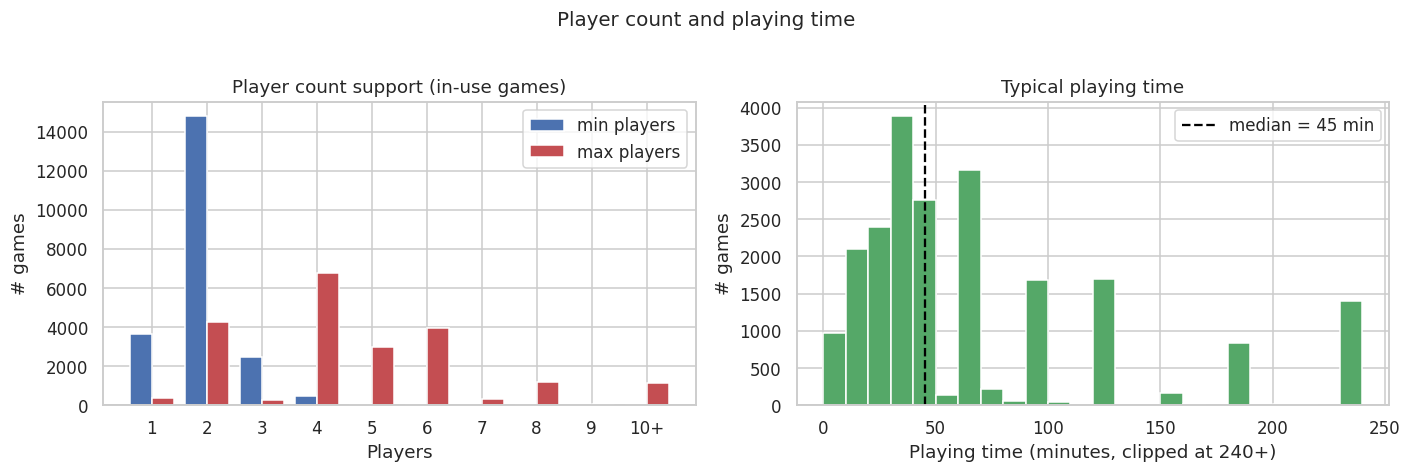

In [20]:
# Plot 6: player counts and playing time (clip the long tail for readability)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Player counts: clip max at 10 for a clean view
mp_clip = maxp.dropna().clip(upper=10).astype(int)
mn_clip = minp.dropna().clip(upper=10).astype(int)

axes[0].hist([mn_clip, mp_clip], bins=np.arange(0.5, 11.5, 1),
             color=['#4C72B0', '#C44E52'], label=['min players', 'max players'],
             edgecolor='white')
axes[0].set_xticks(range(1, 11))
axes[0].set_xticklabels([str(i) for i in range(1, 10)] + ['10+'])
axes[0].set_xlabel('Players')
axes[0].set_ylabel('# games')
axes[0].set_title('Player count support (in-use games)')
axes[0].legend()

# Playing time: clip at 240 min for readability
pt_clip = ptime.dropna().clip(upper=240)
axes[1].hist(pt_clip, bins=np.arange(0, 245, 10), color='#55A868', edgecolor='white')
axes[1].set_xlabel('Playing time (minutes, clipped at 240+)')
axes[1].set_ylabel('# games')
axes[1].set_title('Typical playing time')
axes[1].axvline(pt_clip.median(), color='black', linestyle='--',
                label=f'median = {ptime.median():.0f} min')
axes[1].legend()

plt.suptitle('Player count and playing time', y=1.02, fontsize=13)
plt.tight_layout()
savefig('06_players_time')
plt.show()

## 12. Rating vs. Popularity — the engine of the popularity baseline

If average rating and rating count are uncorrelated, popularity is useless as a signal.
If they're positively correlated, the Bayesian baseline has something to lean on.

  saved -> ./eda_figures/07_rating_vs_popularity.png


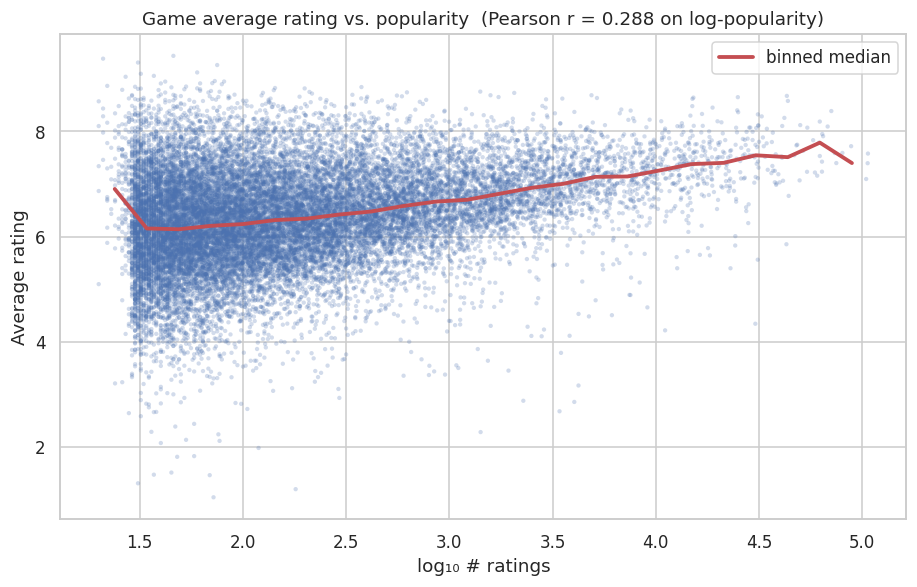

In [21]:
# Plot 7: scatter of avg rating vs log10(n_ratings), per game (filtered)
fig, ax = plt.subplots(figsize=(8.5, 5.5))

n_ratings = g_stats['n_ratings'].values
avg = g_stats['avg_rating'].values
log_n = np.log10(n_ratings)

ax.scatter(log_n, avg, s=8, alpha=0.25, color='#4C72B0', edgecolor='none')

# Overlay a binned median trend so the eye can find the signal through the noise
bins = np.linspace(log_n.min(), log_n.max(), 25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
medians = [np.median(avg[(log_n >= bins[i]) & (log_n < bins[i+1])]) if ((log_n >= bins[i]) & (log_n < bins[i+1])).any() else np.nan
           for i in range(len(bins) - 1)]
ax.plot(bin_centers, medians, color='#C44E52', linewidth=2.5, label='binned median')

corr_p = np.corrcoef(log_n, avg)[0, 1]
ax.set_xlabel('log₁₀ # ratings')
ax.set_ylabel('Average rating')
ax.set_title(f'Game average rating vs. popularity  (Pearson r = {corr_p:.3f} on log-popularity)')
ax.legend()
plt.tight_layout()
savefig('07_rating_vs_popularity')
plt.show()

**Report angle.** There's a clear positive trend: more-rated games tend to be
better-rated. That's the signal the Bayesian shrinkage exploits — when a game has few
ratings, we don't trust its average and pull it toward the global mean, which is
*conservative because* the rare 10-rated obscure game is more likely to be a fluke than
the next Gloomhaven. Quote `r` from the plot title in your report; it's a defensible
single number.

## 13. Per-User Rating Behavior

Different users rate on different scales. Some are generous (mean ~ 8), some are harsh
(mean ~ 5). This matters because the Phase 1 content-based model centers ratings per-user
before building taste profiles — this section justifies that choice.

In [22]:
user_stats = reviews_filt.groupby('user')['rating'].agg(['mean', 'std', 'count']).reset_index()
user_stats = user_stats.rename(columns={'mean': 'user_mean', 'std': 'user_std', 'count': 'n_ratings'})

print(f"# users (filtered): {len(user_stats):,}")
print()
print("User mean rating across the population:")
print(user_stats['user_mean'].describe().round(3).to_string())
print()
print("User rating std (intra-user spread):")
print(user_stats['user_std'].describe().round(3).to_string())

# users (filtered): 272,319

User mean rating across the population:
count    272319.000
mean          7.504
std           0.820
min           1.000
25%           7.000
50%           7.467
75%           8.000
max          10.000

User rating std (intra-user spread):
count    272319.000
mean          1.320
std           0.484
min           0.000
25%           1.008
50%           1.265
75%           1.566
max           4.930


  saved -> ./eda_figures/08_user_behavior.png


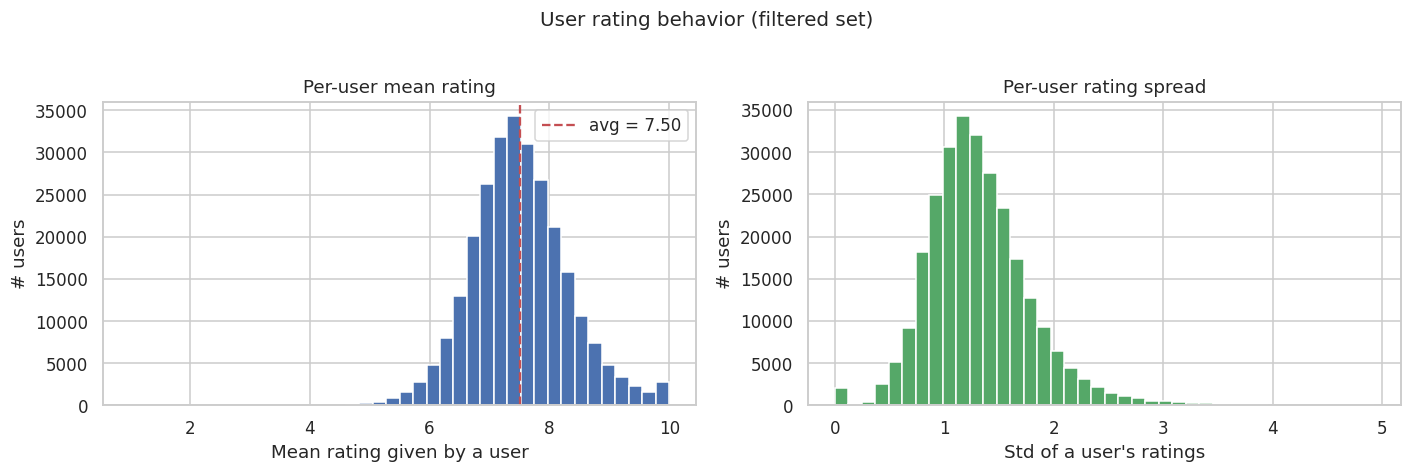

In [23]:
# Plot 8: distribution of per-user mean rating, and per-user std
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(user_stats['user_mean'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].axvline(user_stats['user_mean'].mean(), color='#C44E52', linestyle='--',
                label=f"avg = {user_stats['user_mean'].mean():.2f}")
axes[0].set_xlabel('Mean rating given by a user')
axes[0].set_ylabel('# users')
axes[0].set_title('Per-user mean rating')
axes[0].legend()

axes[1].hist(user_stats['user_std'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[1].set_xlabel('Std of a user\'s ratings')
axes[1].set_ylabel('# users')
axes[1].set_title('Per-user rating spread')

plt.suptitle('User rating behavior (filtered set)', y=1.02, fontsize=13)
plt.tight_layout()
savefig('08_user_behavior')
plt.show()

**Report angle.** Mean ratings cluster around 7 but stretch from ~5 to ~9. A
"predict the global mean" model is wrong by ~1 point for both ends of that. Per-user
centering — like the content-based model uses — directly addresses this.

## 14. Cold-Start Sizing

How big a problem is cold start, really? In the **raw** dataset, a huge fraction of users
have ≤ 3 ratings. After filtering, by construction none do. The gap between those two
numbers is where the cold-start onboarding flow lives.

In [24]:
def cold_start_breakdown(df, label):
    counts = df['user'].value_counts()
    buckets = {
        '1 rating': (counts == 1).sum(),
        '2-3 ratings': ((counts >= 2) & (counts <= 3)).sum(),
        '4-9 ratings': ((counts >= 4) & (counts <= 9)).sum(),
        '10-49 ratings': ((counts >= 10) & (counts <= 49)).sum(),
        '50-199 ratings': ((counts >= 50) & (counts <= 199)).sum(),
        '200+ ratings': (counts >= 200).sum(),
    }
    total = sum(buckets.values())
    return pd.Series({k: f"{v:,} ({100*v/total:.1f}%)" for k, v in buckets.items()}, name=label)

cs_df = pd.concat([
    cold_start_breakdown(reviews_raw, 'raw'),
    cold_start_breakdown(reviews_filt, 'filtered'),
], axis=1)
print(cs_df.to_string())

                            raw         filtered
1 rating         80,252 (19.4%)         0 (0.0%)
2-3 ratings      45,923 (11.1%)         0 (0.0%)
4-9 ratings      61,978 (15.0%)   47,665 (17.5%)
10-49 ratings   131,068 (31.7%)  131,061 (48.1%)
50-199 ratings   73,230 (17.7%)   73,229 (26.9%)
200+ ratings      20,364 (4.9%)    20,364 (7.5%)


  saved -> ./eda_figures/09_cold_start_cohorts.png


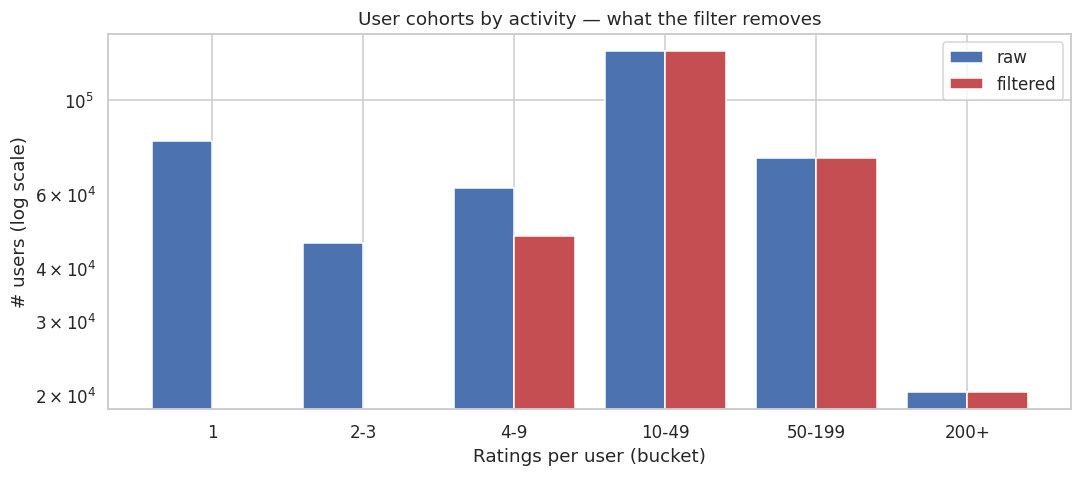

In [25]:
# Plot 9: user-cohort bar chart, raw vs filtered
fig, ax = plt.subplots(figsize=(10, 4.5))

cohort_labels = ['1', '2-3', '4-9', '10-49', '50-199', '200+']
raw_counts = reviews_raw['user'].value_counts()
filt_counts = reviews_filt['user'].value_counts()

def bucket(counts):
    return [
        (counts == 1).sum(),
        ((counts >= 2) & (counts <= 3)).sum(),
        ((counts >= 4) & (counts <= 9)).sum(),
        ((counts >= 10) & (counts <= 49)).sum(),
        ((counts >= 50) & (counts <= 199)).sum(),
        (counts >= 200).sum(),
    ]

x = np.arange(len(cohort_labels))
w = 0.4
ax.bar(x - w/2, bucket(raw_counts), w, label='raw', color='#4C72B0', edgecolor='white')
ax.bar(x + w/2, bucket(filt_counts), w, label='filtered', color='#C44E52', edgecolor='white')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(cohort_labels)
ax.set_xlabel('Ratings per user (bucket)')
ax.set_ylabel('# users (log scale)')
ax.set_title('User cohorts by activity — what the filter removes')
ax.legend()
plt.tight_layout()
savefig('09_cold_start_cohorts')
plt.show()

**Report angle.** Roughly half of all raw users are the lightest cohort
(1 rating) and are completely removed by the filter. Your deployed app will see new users
in this state on day one — which is the motivation for the cold-start onboarding step in
the Phase 2 architecture (BPR-style SGD on frozen embeddings, seeded from a few
onboarding ratings).

## 15. Train / Val / Test Split

The Phase 1 evaluation harness is leave-one-out per user (one held-out for val, one for
test, the rest for train). We replicate the split here so the EDA reports the exact same
shapes as the modeling notebook.

In [26]:
from sklearn.preprocessing import LabelEncoder

# Encode users/games (only needed to make the split function match Phase 1 exactly)
user_enc = LabelEncoder()
game_enc = LabelEncoder()
reviews_filt['user_idx'] = user_enc.fit_transform(reviews_filt['user'])
reviews_filt['game_idx'] = game_enc.fit_transform(reviews_filt['game_id'])

def leave_one_out_split(df, seed=SEED):
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    df['_rank'] = df.groupby('user_idx').cumcount()
    test = df[df['_rank'] == 0]
    val = df[df['_rank'] == 1]
    train = df[df['_rank'] >= 2]
    return (train.drop(columns='_rank'),
            val.drop(columns='_rank'),
            test.drop(columns='_rank'))

train_df, val_df, test_df = leave_one_out_split(reviews_filt)
split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'pct': 100*len(train_df)/len(reviews_filt)},
    {'split': 'val',   'rows': len(val_df),   'pct': 100*len(val_df)/len(reviews_filt)},
    {'split': 'test',  'rows': len(test_df),  'pct': 100*len(test_df)/len(reviews_filt)},
])
split_summary['rows'] = split_summary['rows'].apply(lambda x: f"{x:,}")
split_summary['pct'] = split_summary['pct'].apply(lambda x: f"{x:.2f}%")
print(split_summary.to_string(index=False))

split       rows    pct
train 18,171,881 97.09%
  val    272,319  1.45%
 test    272,319  1.45%


  saved -> ./eda_figures/10_split_sanity.png


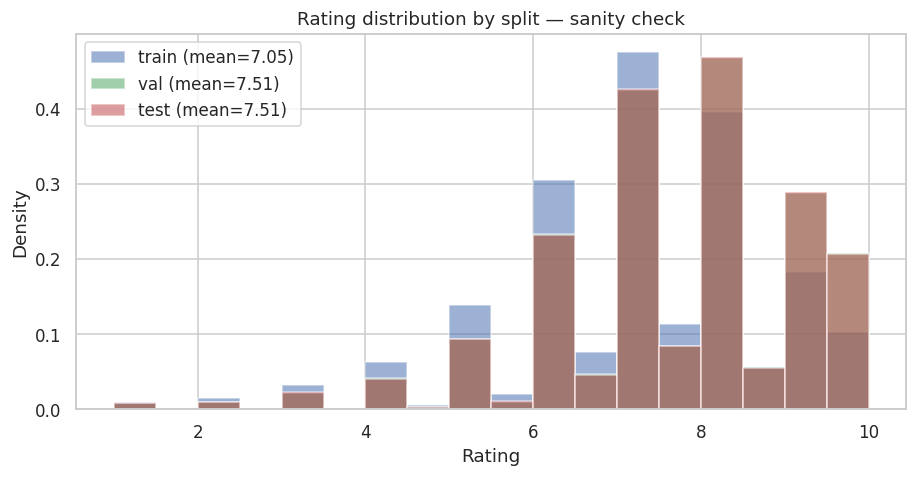

In [27]:
# Plot 10: rating distribution per split — sanity check that the split is unbiased
fig, ax = plt.subplots(figsize=(8.5, 4.5))

bins = np.arange(1.0, 10.5, 0.5)
for label, df, color in [('train', train_df, '#4C72B0'),
                         ('val',   val_df,   '#55A868'),
                         ('test',  test_df,  '#C44E52')]:
    ax.hist(df['rating'], bins=bins, alpha=0.55, label=f'{label} (mean={df["rating"].mean():.2f})',
            color=color, edgecolor='white', density=True)
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_title('Rating distribution by split — sanity check')
ax.legend()
plt.tight_layout()
savefig('10_split_sanity')
plt.show()

**Report angle.** Train/val/test distributions overlap almost perfectly — the
random LOO split doesn't introduce a systematic shift. Any RMSE gap between train and
test in the modeling notebook is genuine generalization error, not a split artifact.

## 16. Headline Numbers (for the report)

A single block of numbers your report can quote without rerunning the notebook.

In [28]:
headline = {
    'Raw reviews':                 f"{len(reviews_raw):,}",
    'Raw users':                   f"{reviews_raw['user'].nunique():,}",
    'Raw games':                   f"{reviews_raw['game_id'].nunique():,}",
    'Filtered reviews':            f"{len(reviews_filt):,}",
    'Filtered users':              f"{reviews_filt['user'].nunique():,}",
    'Filtered games':              f"{reviews_filt['game_id'].nunique():,}",
    'Filter survival (rows)':      f"{100*len(reviews_filt)/len(reviews_raw):.2f}%",
    'Filter survival (users)':     f"{100*reviews_filt['user'].nunique()/reviews_raw['user'].nunique():.2f}%",
    'Filter survival (games)':     f"{100*reviews_filt['game_id'].nunique()/reviews_raw['game_id'].nunique():.2f}%",
    'Global mean rating (filt.)':  f"{reviews_filt['rating'].mean():.3f}",
    'Global std rating (filt.)':   f"{reviews_filt['rating'].std():.3f}",
    'Median ratings/user (filt.)': f"{int(reviews_filt['user'].value_counts().median())}",
    'Median ratings/game (filt.)': f"{int(reviews_filt['game_id'].value_counts().median())}",
    'Sparsity (filtered)':         f"{100*(1 - len(reviews_filt)/(reviews_filt['user'].nunique()*reviews_filt['game_id'].nunique())):.4f}%",
    'Train rows':                  f"{len(train_df):,}",
    'Val rows':                    f"{len(val_df):,}",
    'Test rows':                   f"{len(test_df):,}",
}

print("=" * 50)
print("BGG EDA — Headline Numbers")
print("=" * 50)
for k, v in headline.items():
    print(f"{k:<32} {v:>15}")
print("=" * 50)

# Also save as CSV for easy reference / pasting into a report
pd.Series(headline, name='value').to_csv(f"{FIG_DIR}/headline_numbers.csv")
print(f"\nSaved to {FIG_DIR}/headline_numbers.csv")
print(f"All figures in:  {FIG_DIR}/")

BGG EDA — Headline Numbers
Raw reviews                           18,964,728
Raw users                                412,815
Raw games                                 21,839
Filtered reviews                      18,716,519
Filtered users                           272,319
Filtered games                            21,802
Filter survival (rows)                    98.69%
Filter survival (users)                   65.97%
Filter survival (games)                   99.83%
Global mean rating (filt.)                 7.063
Global std rating (filt.)                  1.586
Median ratings/user (filt.)                   29
Median ratings/game (filt.)                  120
Sparsity (filtered)                     99.6848%
Train rows                            18,171,881
Val rows                                 272,319
Test rows                                272,319

Saved to ./eda_figures/headline_numbers.csv
All figures in:  ./eda_figures/


---

That's the dataset. Ten plots, two summary tables, and the headline numbers above.
Drop the PNGs from `./eda_figures/` straight into the report; lift the prose under each
**Report angle** callout for figure captions or section intros.